In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../datasets/sales_data_cln.csv").copy()

In [3]:
# co: completed_orders
co = df[df["refund_ts"].isna()]

In [4]:
co.columns

Index(['user_id', 'order_id', 'purchase_ts', 'ship_ts', 'refund_ts',
       'product_name', 'product_id', 'usd_price', 'purchase_platform',
       'marketing_channel', 'account_creation_method', 'country_code',
       'purchase_y', 'purchase_ym', 'purchase_ymd', 'purchase_ymw',
       'purchase_q', 'ship_y', 'ship_ym', 'ship_ymd', 'ship_ymw', 'ship_q'],
      dtype='object')

In [5]:
co["product_name"].unique()

array(['Nintendo Switch', '27in 4K gaming monitor',
       'JBL Quantum 100 Gaming Headset', 'Sony PlayStation 5 Bundle',
       'Dell Gaming Mouse', 'Acer Nitro V Gaming Laptop',
       'Lenovo IdeaPad Gaming 3', 'Razer Pro Gaming Headset',
       '27inches 4k gaming monitor'], dtype=object)

In [6]:
prod_rev_ym = co.groupby(["purchase_ym", "product_name"]).agg(total_revenue=("usd_price", "sum"), total_orders = ("order_id", "count")).reset_index()

prod_rev_ym

,purchase_ym,product_name,total_revenue,total_orders
0,2019-01,27in 4K gaming monitor,27756.61,71
1,2019-01,27inches 4k gaming monitor,1812.66,5
2,2019-01,Acer Nitro V Gaming Laptop,2298.04,3
3,2019-01,JBL Quantum 100 Gaming Headset,2754.80,120
4,2019-01,Lenovo IdeaPad Gaming 3,4532.49,4
...,...,...,...,...
188,2021-02,Dell Gaming Mouse,2938.56,56
189,2021-02,JBL Quantum 100 Gaming Headset,2780.89,137
190,2021-02,Lenovo IdeaPad Gaming 3,23309.02,20
191,2021-02,Nintendo Switch,42120.11,256


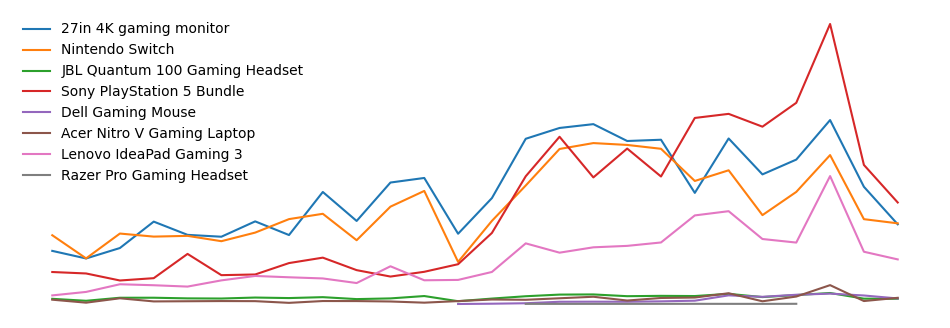

In [9]:
fig, ax = plt.subplots(figsize=(12, 4))

# ax.bar(rev_data_ym["order_year_month"], rev_data_ym["total_net_revenue"], label='Product A', color='#4dabf7')

prod_01 = prod_rev_ym[(prod_rev_ym["product_name"] == "27in 4K gaming monitor")]
prod_02 = prod_rev_ym[prod_rev_ym["product_name"] == "Nintendo Switch"]
prod_03 = prod_rev_ym[prod_rev_ym["product_name"] == "JBL Quantum 100 Gaming Headset"]
prod_04 = prod_rev_ym[prod_rev_ym["product_name"] == "Sony PlayStation 5 Bundle"]
prod_05 = prod_rev_ym[prod_rev_ym["product_name"] == "Dell Gaming Mouse"]
prod_06 = prod_rev_ym[prod_rev_ym["product_name"] == "Acer Nitro V Gaming Laptop"]
prod_07 = prod_rev_ym[prod_rev_ym["product_name"] == "Lenovo IdeaPad Gaming 3"]
prod_08 = prod_rev_ym[prod_rev_ym["product_name"] == "Razer Pro Gaming Headset"]


ax.plot(prod_01["purchase_ym"], prod_01["total_revenue"], label = "27in 4K gaming monitor")
ax.plot(prod_02["purchase_ym"], prod_02["total_revenue"], label = "Nintendo Switch")
ax.plot(prod_03["purchase_ym"], prod_03["total_revenue"], label = "JBL Quantum 100 Gaming Headset")
ax.plot(prod_04["purchase_ym"], prod_04["total_revenue"], label = "Sony PlayStation 5 Bundle")
ax.plot(prod_05["purchase_ym"], prod_05["total_revenue"], label = "Dell Gaming Mouse")
ax.plot(prod_06["purchase_ym"], prod_06["total_revenue"], label = "Acer Nitro V Gaming Laptop")
ax.plot(prod_07["purchase_ym"], prod_07["total_revenue"], label = "Lenovo IdeaPad Gaming 3")
ax.plot(prod_08["purchase_ym"], prod_08["total_revenue"], label = "Razer Pro Gaming Headset")

# ax.scatter(rev_data_ym["order_year_month"], rev_data_ym["gross_margin"])

ax.legend(frameon = False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.axes.get_xaxis().set_visible(False)
ax.axes.get_yaxis().set_visible(False)
# ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
ax.axes.xaxis.set_ticklabels([])
ax.axes.yaxis.set_ticklabels([])
plt.savefig("../figures/product_performance/product_performance.png", transparent=True, dpi=300)
# ax.set_title("GROSS MARGIN PER MONTH")

plt.show()

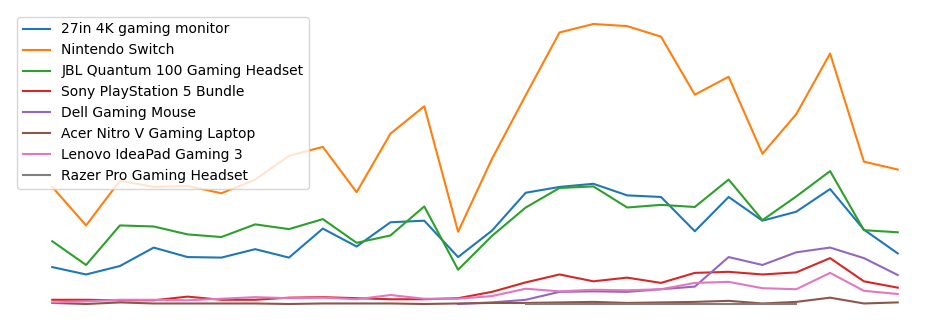

In [8]:
fig, ax = plt.subplots(figsize=(12, 4))

# ax.bar(rev_data_ym["order_year_month"], rev_data_ym["total_net_revenue"], label='Product A', color='#4dabf7')

prod_01 = prod_rev_ym[(prod_rev_ym["product_name"] == "27in 4K gaming monitor")]
prod_02 = prod_rev_ym[prod_rev_ym["product_name"] == "Nintendo Switch"]
prod_03 = prod_rev_ym[prod_rev_ym["product_name"] == "JBL Quantum 100 Gaming Headset"]
prod_04 = prod_rev_ym[prod_rev_ym["product_name"] == "Sony PlayStation 5 Bundle"]
prod_05 = prod_rev_ym[prod_rev_ym["product_name"] == "Dell Gaming Mouse"]
prod_06 = prod_rev_ym[prod_rev_ym["product_name"] == "Acer Nitro V Gaming Laptop"]
prod_07 = prod_rev_ym[prod_rev_ym["product_name"] == "Lenovo IdeaPad Gaming 3"]
prod_08 = prod_rev_ym[prod_rev_ym["product_name"] == "Razer Pro Gaming Headset"]


ax.plot(prod_01["purchase_ym"], prod_01["total_orders"], label = "27in 4K gaming monitor")
ax.plot(prod_02["purchase_ym"], prod_02["total_orders"], label = "Nintendo Switch")
ax.plot(prod_03["purchase_ym"], prod_03["total_orders"], label = "JBL Quantum 100 Gaming Headset")
ax.plot(prod_04["purchase_ym"], prod_04["total_orders"], label = "Sony PlayStation 5 Bundle")
ax.plot(prod_05["purchase_ym"], prod_05["total_orders"], label = "Dell Gaming Mouse")
ax.plot(prod_06["purchase_ym"], prod_06["total_orders"], label = "Acer Nitro V Gaming Laptop")
ax.plot(prod_07["purchase_ym"], prod_07["total_orders"], label = "Lenovo IdeaPad Gaming 3")
ax.plot(prod_08["purchase_ym"], prod_08["total_orders"], label = "Razer Pro Gaming Headset")

# ax.scatter(rev_data_ym["order_year_month"], rev_data_ym["gross_margin"])

ax.legend()

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.axes.get_xaxis().set_visible(False)
ax.axes.get_yaxis().set_visible(False)
# ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
ax.axes.xaxis.set_ticklabels([])
ax.axes.yaxis.set_ticklabels([])
plt.savefig("../figures/product_performance/product_performance_orders.png", transparent=True, dpi=300)
# ax.set_title("GROSS MARGIN PER MONTH")

plt.show()